# Homework part I

The first problem set contains basic tasks in PyTorch.

__Note:__ Instead of doing this part of homework, you can prove your skills otherwise:
* A commit to PyTorch or PyTorch-based repos will do;
* Fully implemented seminar assignment in tensorflow or theano will do;
* Your own project in PyTorch that is developed to a state in which a normal human can understand and appreciate what it does.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import torch, torch.nn as nn
import torch.nn.functional as F
print(torch.__version__)

2.8.0+cu126


### Task I - tensormancy

![img](https://media.giphy.com/media/3o751UMCYtSrRAFRFC/giphy.gif)

When dealing with more complex stuff like neural network, it's best if you use tensors the way samurai uses his sword.


__1.1 The Cannabola__
[(_disclaimer_)](https://gist.githubusercontent.com/justheuristic/e2c1fa28ca02670cabc42cacf3902796/raw/fd3d935cef63a01b85ed2790b5c11c370245cbd7/stddisclaimer.h)

Let's write another function, this time in polar coordinates:
$$\rho(\theta) = (1 + 0.9 \cdot cos (8 \cdot \theta) ) \cdot (1 + 0.1 \cdot cos(24 \cdot \theta)) \cdot (0.9 + 0.05 \cdot cos(200 \cdot \theta)) \cdot (1 + sin(\theta))$$


Then convert it into cartesian coordinates ([howto](http://www.mathsisfun.com/polar-cartesian-coordinates.html)) and plot the results.

Use torch tensors only: no lists, loops, numpy arrays, etc.

/tmp/ipython-input-1324348266.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  x = (rho * np.cos(theta))
/tmp/ipython-input-1324348266.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y = (rho * np.sin(theta))


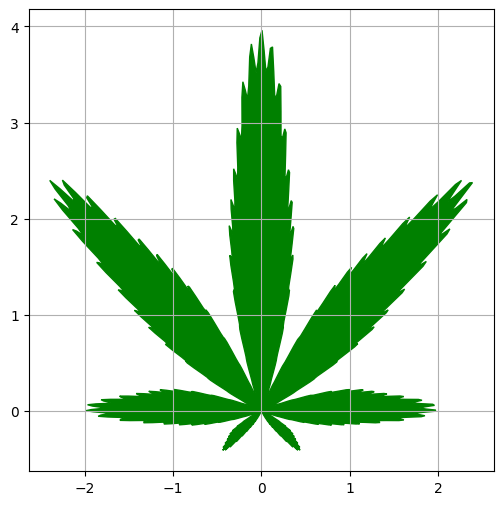

In [4]:
import torch

theta = torch.linspace(-np.pi, np.pi, steps=1000)

# compute rho(theta) as per formula above
rho = (1+0.9*torch.cos(8*theta))*(1+0.1* torch.cos(24*theta))*(0.9+0.05*torch.cos(200*theta))*(1+ torch.sin(theta))

# Now convert polar (rho, theta) pairs into cartesian (x,y) to plot them.
x = (rho * np.cos(theta))

y = (rho * np.sin(theta))


plt.figure(figsize=[6, 6])
plt.fill(x.numpy(), y.numpy(), color='green')
plt.grid()

### Task II: The Game of Life

Now it's time for you to make something more challenging. We'll implement Conway's [Game of Life](http://web.stanford.edu/~cdebs/GameOfLife/) in _pure PyTorch_.

While this is still a toy task, implementing game of life this way has one cool benefit: __you'll be able to run it on GPU!__ Indeed, what could be a better use of your GPU than simulating Game of Life on 1M/1M grids?

![img](https://upload.wikimedia.org/wikipedia/commons/e/e5/Gospers_glider_gun.gif)

If you've skipped the URL above out of sloth, here's the Game of Life:
* You have a 2D grid of cells, where each cell is "alive"(1) or "dead"(0)
* Any living cell that has 2 or 3 neighbors survives, else it dies [0,1 or 4+ neighbors]
* Any cell with exactly 3 neighbors becomes alive (if it was dead)

For this task, you are given a reference NumPy implementation that you must convert to PyTorch.
_[NumPy code inspired by: https://github.com/rougier/numpy-100]_


__Note:__ You can find convolution in `torch.nn.functional.conv2d(Z,filters)`. Note that it has a different input format.

__Note 2:__ From the mathematical standpoint, PyTorch convolution is actually cross-correlation. Those two are very similar operations. More info: [video tutorial](https://www.youtube.com/watch?v=C3EEy8adxvc), [scipy functions review](http://programmerz.ru/questions/26903/2d-convolution-in-python-similar-to-matlabs-conv2-question), [stack overflow source](https://stackoverflow.com/questions/31139977/comparing-matlabs-conv2-with-scipys-convolve2d).

In [52]:
from scipy.signal import correlate2d

def np_update(Z):
    # Count neighbours with convolution
    filters = np.array([[1, 1, 1],
                        [1, 0, 1],
                        [1, 1, 1]])

    N = correlate2d(Z, filters, mode='same')

    # Apply rules
    birth = (N == 3) & (Z == 0)
    survive = ((N == 2) | (N == 3)) & (Z == 1)

    Z[:] = birth | survive
    return Z

In [56]:
def torch_update(Z):
    """
    Implement an update function that does to Z exactly the same as np_update.
    :param Z: torch.FloatTensor of shape [height,width] containing 0s(dead) an 1s(alive)
    :returns: torch.FloatTensor Z after updates.

    You can opt to create new tensor or change Z inplace.
    """

    filters = torch.tensor([[1, 1, 1],
                            [1, 0, 1],
                            [1, 1, 1]], dtype=torch.float32
                           )
    #print(filters, filters.shape)
    #print(filters.unsqueeze(0), filters.unsqueeze(0).shape)

    N = torch.nn.functional.conv2d(Z.unsqueeze(0).unsqueeze(0), filters.unsqueeze(0).unsqueeze(0), padding=1)
    #print(N.shape, Z.shape)
    N = N.squeeze(0).squeeze(0)
    #print(N.shape, Z.shape)
    birth = (N == 3) & (Z == 0)
    survive = ((N == 2) | (N == 3)) & (Z == 1)

    Z[:] = birth | survive
    return Z


In [57]:
# initial frame
Z_numpy = np.random.choice([0, 1], p=(0.5, 0.5), size=(5, 5))
Z = torch.from_numpy(Z_numpy).type(torch.FloatTensor)

print(Z)
# your debug polygon :)
Z_new = torch_update(Z.clone())

# tests
Z_reference = np_update(Z_numpy.copy())
assert np.all(Z_new.numpy() == Z_reference), \
    "your PyTorch implementation doesn't match np_update. Look into Z and np_update(ZZ) to investigate."
print("Well done!")

tensor([[0., 0., 1., 0., 1.],
        [1., 1., 1., 1., 1.],
        [0., 1., 0., 0., 1.],
        [0., 0., 0., 1., 0.],
        [0., 1., 1., 0., 1.]])
Well done!


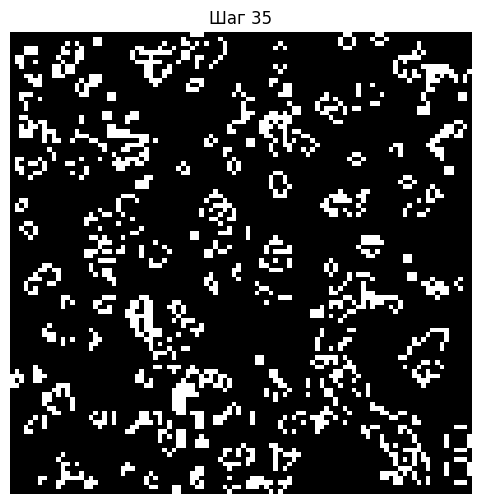

KeyboardInterrupt: 

In [79]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# Убедитесь, что используется inline (по умолчанию в Colab)
%matplotlib inline

# Инициализация
Z = np.random.choice([0, 1], size=(100, 100))

Z = np.random.choice([0, 1], p=(0.5, 0.5), size=(100, 100))
Z = torch.from_numpy(Z).type(torch.FloatTensor)

# Анимация
for step in range(100):
    clear_output(wait=True)  # Очищает предыдущий вывод

    plt.figure(figsize=(6, 6))
    plt.imshow(Z.numpy(), cmap='gray', vmin=0, vmax=1)
    plt.title(f"Шаг {step}")
    plt.axis('off')
    plt.show()

    Z = torch_update(Z)
    time.sleep(0.5)  # Задержка для плавности

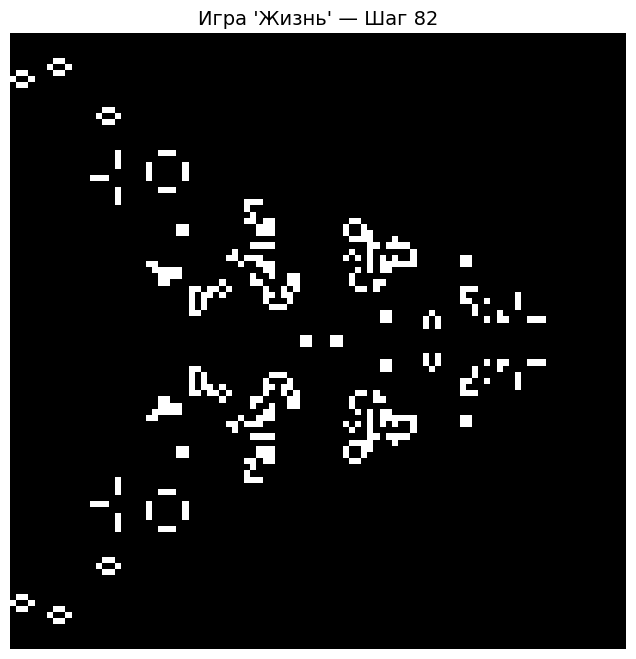

KeyboardInterrupt: 

In [67]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

%matplotlib inline

# --- Инициализация "полосатого" поля ---
Z = np.arange(100) % 2 + np.zeros([100, 100])
Z[48:52, 50] = 1  # небольшой дефект
Z = torch.from_numpy(Z).type(torch.FloatTensor)

# --- Анимация в Colab ---
for step in range(100):
    clear_output(wait=True)

    plt.figure(figsize=(8, 8))
    plt.imshow(Z.numpy(), cmap='gray', vmin=0, vmax=1)
    plt.title(f"Игра 'Жизнь' — Шаг {step}", fontsize=14)
    plt.axis('off')
    plt.show()

    Z = torch_update(Z)
    time.sleep(0.5)

More fun with Game of Life: [video](https://www.youtube.com/watch?v=C2vgICfQawE) and/or [Jupyter Notebook](https://nbviewer.jupyter.org/url/norvig.com/ipython/Life.ipynb)

### Task III: Going deeper
<img src="https://www.meme-arsenal.com/memes/00ad90d844e491aaeb6892515c716710.jpg" width=360>

Your third trial is to build your first neural network [almost] from scratch and pure PyTorch.

This time you will solve yet another digit recognition problem, but at a greater scale

* 10 different letters
* 20k samples

We want you to build a network that reaches at least 80% accuracy and has at least 2 linear layers in it. Naturally, it should be nonlinear to beat logistic regression.


With 10 classes you will need to use __Softmax__ at the top instead of sigmoid and train using __categorical crossentropy__ .  Write your own loss or use `torch.nn.functional.nll_loss`. Just make sure you understand what it accepts as input.

Note that you are not required to build 152-layer monsters here. A 2-layer (one hidden, one output) neural network should already give you an edge over logistic regression.


__[bonus kudos]__
If you've already beaten logistic regression with a two-layer net, but enthusiasm still ain't gone, you can try improving the test accuracy even further! It should be possible to reach 90% without convnets.

__SPOILERS!__
At the end of the notebook you will find a few tips and frequent errors.
If you feel confident enough, just start coding right away and get there ~~if~~ once you need to untangle yourself.

In [80]:
!wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_DL/fall21/week02_autodiff/notmnist.py

In [81]:
from notmnist import load_notmnist
X_train, y_train, X_test, y_test = load_notmnist(letters='ABCDEFGHIJ')
X_train, X_test = X_train.reshape([-1, 784]), X_test.reshape([-1, 784])

Extracting ...
Parsing...
found broken img: ./notMNIST_small/A/RGVtb2NyYXRpY2FCb2xkT2xkc3R5bGUgQm9sZC50dGY=.png [it's ok if <10 images are broken]
found broken img: ./notMNIST_small/F/Q3Jvc3NvdmVyIEJvbGRPYmxpcXVlLnR0Zg==.png [it's ok if <10 images are broken]
Done


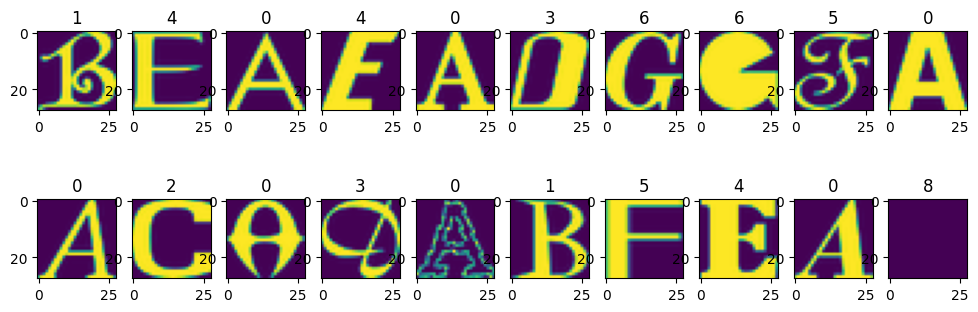

In [82]:
%matplotlib inline
plt.figure(figsize=[12, 4])
for i in range(20):
    plt.subplot(2, 10, i+1)
    plt.imshow(X_train[i].reshape([28, 28]))
    plt.title(str(y_train[i]))

In [117]:
model = nn.Sequential(
    nn.Linear(784, 32),
    nn.ReLU(),
    nn.Linear(32, 10),
    nn.Softmax(dim=1)
)

In [118]:
x = torch.tensor(X_train[:3])
y = torch.tensor(y_train[:3])

x, y, x.shape, y.shape

(tensor([[-0.9275, -0.9275, -0.9275,  ..., -0.9189, -0.9275, -0.9275],
         [ 0.0644,  0.4150,  0.3722,  ...,  0.0559, -0.2862, -0.8591],
         [-0.9275, -0.9275, -0.9275,  ...,  1.2530,  1.2530,  0.6202]]),
 tensor([1, 4, 0]),
 torch.Size([3, 784]),
 torch.Size([3]))

In [119]:
w = [w for w in model.parameters()]
y_pred = model(x)
print(torch.argmax(y_pred, axis=1))
print(len(w))
y_pred

tensor([9, 3, 0])
4


tensor([[0.0967, 0.0859, 0.0913, 0.1042, 0.0947, 0.0892, 0.1018, 0.1142, 0.0853,
         0.1366],
        [0.0813, 0.0946, 0.0684, 0.1534, 0.1163, 0.0943, 0.1324, 0.1230, 0.0799,
         0.0564],
        [0.1297, 0.1170, 0.0808, 0.1248, 0.1009, 0.0719, 0.1080, 0.1214, 0.0699,
         0.0756]], grad_fn=<SoftmaxBackward0>)

In [ ]:
!pip install --upgrade sympy
import sympy
print(sympy.__version__)

In [124]:
def crosentropy(y, y_pred):
  return -torch.sum(y * torch.log(y_pred))

history = []
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

loss = cat_crossentropy(y, y_pred)

epochs = 150
print("grad of loss at the beginning = ", loss.grad())
for i in range(epochs):
  ixs = np.random.randint(0, len(X_train), 256)
  x_batch = torch.tensor(X_train[ixs])
  y_batch = torch.tensor(y_train[ixs])

  y_predicted = model(x_batch)

  assert y_predicted.dim() == 10

  loss = cat_crossentropy

  loss.backward()
  opt.step()
  loss.zero_grad()

AttributeError: module 'sympy' has no attribute 'printing'

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

# SPOILERS!

Recommended pipeline:

* Adapt logistic regression from seminar assignment to classify one letter against others (e.g. A vs the rest)
* Generalize it to multiclass logistic regression.
  - Either try to remember lecture 0 or google it.
  - Instead of weight vector you'll have to use matrix (feature_id x class_id)
  - Softmax (exp over sum of exps) can be implemented manually or as `nn.Softmax` (layer) or `F.softmax` (function)
  - Probably better to use STOCHASTIC gradient descent (minibatch) for greater speed
    - You can also try momentum/rmsprop/adawhatever
    - in which case the dataset should probably be shuffled (or use random subsamples on each iteration)
* Add a hidden layer. Now your logistic regression uses hidden neurons instead of inputs.
  - Hidden layer uses the same math as output layer (ex-logistic regression), but uses some nonlinearity (e.g. sigmoid) instead of softmax
  - You need to train both layers, not just the output layer :)
  - 50 hidden neurons and a sigmoid nonlinearity will do for a start. Many ways to improve.
  - In ideal case this totals to 2 `torch.matmul`'s, 1 softmax and 1 ReLU/sigmoid
  - __Make sure this neural network works better than logistic regression!__

* Now's the time to try improving the network. Consider layers (size, neuron count), nonlinearities, optimization methods, initialization — whatever you want, but please avoid convolutions for now.

* If anything seems wrong, try going through one step of training and printing everything you compute.
* If you see NaNs midway through optimization, you can estimate $\log P(y \mid x)$ as `F.log_softmax(layer_before_softmax)`.